In [1]:
import torch
import math
from pyDOE import lhs   # or scipy.stats.qmc.LatinHypercube
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import trange
import gc
import logging
from torch.func import jacrev, vmap, hessian, jacfwd
from torch.utils.data import TensorDataset, DataLoader
import random
import scipy.io
import torch.nn.init as init
logging.getLogger("torch").setLevel(logging.ERROR)
np.random.seed(1234)
torch.manual_seed(1234)
device = torch.device('cuda:2')

In [2]:
class DeepMLP(nn.Module):
    def __init__(self, layer_sizes,x_x_scalers,activation):
        super().__init__()
        self.activation = activation

        weights, biases = [], []
        
        for idx in range(1, len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[idx - 1], layer_sizes[idx]
            if idx == 1:
                weights.append(nn.Parameter(torch.randn(1, out_dim) * x_x_scalers))
                biases.append(nn.Parameter(torch.empty(in_dim, out_dim).uniform_(-1.0, 1.0)))

            else:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                biases.append(nn.Parameter(torch.zeros(1, out_dim)))
                

        std = (1.0 / layer_sizes[-2]) ** 0.5
        w = nn.Parameter(torch.randn(layer_sizes[-2], layer_sizes[-1]) * std)
        weights.append(w)
        biases.append(nn.Parameter(torch.zeros(1, layer_sizes[-1])))     
        
        
        self.W = nn.ParameterList(weights)
        self.b = nn.ParameterList(biases)
        

    
    def forward(self, x, x_min, x_max):

        features = []
        A = 2.0 * (x - x_min) / (x_max - x_min) - 1.0
        
        for i in range(len(self.W) - 1):
            if i == 0:
                A = self.activation(A @ self.W[i] - self.W[i] * self.b[i])
            else:
                A = self.activation(A @ self.W[i] + self.b[i])
        features.append(A)

        y = A @ self.W[-1] + self.b[-1]
        
        return y , features

In [3]:
class Separable2DNet(nn.Module):
    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()
        a_x_scalers, a_y_scalers = 10.0, 10.0
        self.branch_x = DeepMLP(layer_sizes,a_x_scalers, activation=activation)
        self.branch_y = DeepMLP(layer_sizes,a_y_scalers,  activation=activation)
        
        self.final_linear = nn.Linear(layer_sizes[-1], 1)       
        std = (1.0/ layer_sizes[-1]) ** 0.5 
        init.normal_(self.final_linear.weight, mean=0.0, std=std)
        init.zeros_(self.final_linear.bias)
        
        mins = torch.zeros(2, 1)
        maxs = torch.ones(2, 1)
        self.register_buffer("mins", mins)
        self.register_buffer("maxs", maxs)

    def set_bounds(self, mins, maxs):
        
        self.mins.copy_(mins)
        self.maxs.copy_(maxs)

    def forward(self, X_star):
        x = X_star[:, 0:1]
        y = X_star[:, 1:2]

        yx, feat_x = self.branch_x(x, self.mins[0:1], self.maxs[0:1])
        yy, feat_y = self.branch_y(y, self.mins[1:2], self.maxs[1:2])

        outer_product = yx * yy
        y_pred = self.final_linear(outer_product)
        return y_pred, (feat_x, feat_y)

In [4]:
def u_target(t, x):
    freq = 180
    return torch.cos(4* math.pi * x) * torch.cos(freq * math.pi * t) \
           + 0.1* x * (1 - x) * torch.cos(2 * math.pi * t)


def f_target(t, x):
    freq = 180
    u = u_target(t, x)

    term1 = -(((freq * math.pi) ** 2) - ((4 * math.pi) ** 2)) \
            * torch.cos(4 * math.pi * x) * torch.cos(freq * math.pi * t)

    term2 = -(2 * math.pi) ** 2 * x * (1 - x) * torch.cos(2 * math.pi * t)

    term3 = 2 * torch.cos(2 * math.pi * t)

    return term1 + 0.1* term2 +0.1* term3 + u ** 3

In [5]:
axis = torch.linspace(0, 1.0, 100).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

layers = [1] + [300] * 5
model = Separable2DNet(layers).to(device)

# once per dataset
mins = torch.tensor([[0], [0]], device=device)
maxs = torch.tensor([[1.0], [1.0]], device=device)
model.set_bounds(mins, maxs)
    
with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

cube_ref = y_ref.view(len(axis), len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis)).cpu().numpy()

Error(L2): 1.87113e+00


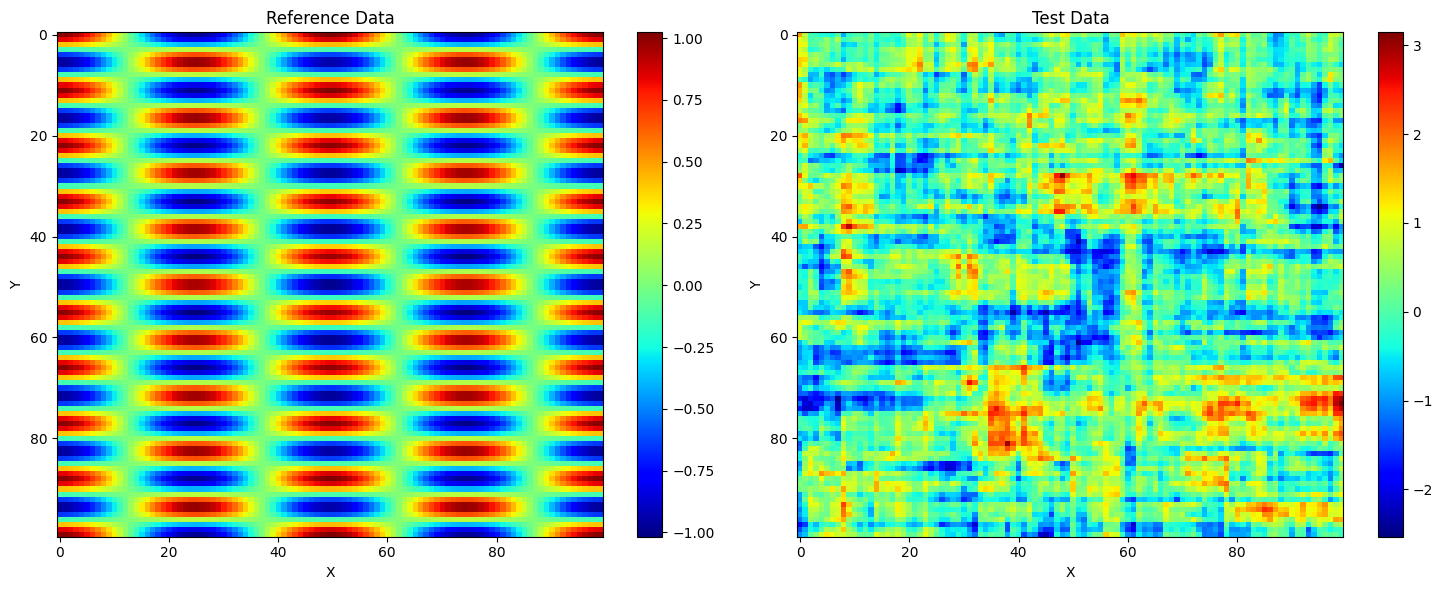

In [6]:
# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 绘制参考数据
im1 = ax1.imshow(cube_ref, cmap='jet', aspect='auto')
ax1.set_title('Reference Data')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
plt.colorbar(im1, ax=ax1)

# 绘制测试数据
im2 = ax2.imshow(cube_test, cmap='jet', aspect='auto')
ax2.set_title('Test Data')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [7]:
def sample_pde_points(N_f, Xmin, Xmax, device):
    """Latin hypercube samples inside [Xmin, Xmax] and their target PDE values."""
    lhs_samples = lhs(2, N_f)
    coords = Xmin + torch.tensor(lhs_samples, dtype=torch.float32, device=device) * (Xmax - Xmin)
    targets = f_target(coords[:, 0:1], coords[:, 1:2])
    return coords, targets.detach()

def sample_boundary_points(N_b, Xmin, Xmax, device):

    r = torch.rand(N_b, 1, device=device)
    t_span = Xmin[0] + (Xmax[0] - Xmin[0]) * r
    
    r676 = torch.rand(1366, 1, device=device)
    x_span = Xmin[1] + (Xmax[1] - Xmin[1]) * r676 
    boundary = torch.cat((
        torch.cat([t_span, torch.full_like(t_span, Xmin[1])], dim=1),
        torch.cat([t_span, torch.full_like(t_span, Xmax[1])], dim=1),
        torch.cat([torch.full_like(x_span, Xmin[0]), x_span], dim=1)
    ), dim=0)

    targets = u_target(boundary[:, 0:1], boundary[:, 1:2])

    return boundary, targets

def sample_initial_points(N_b, Xmin, Xmax, device):
    
    r = torch.rand(4096, 1, device=device)
    x_span = Xmin[1] + (Xmax[1] - Xmin[1]) * r
    boundary = torch.cat([torch.full_like(x_span, Xmin[0]), x_span], dim=1)
    
    targets = u_target(boundary[:, 0:1], boundary[:, 1:2])
    
    return boundary, targets*0

In [8]:
def compute_pde_loss(model, coords, target_pde, criterion):
    """计算 PDE 残差损失：u_xx + u_yy + u"""
    coords.requires_grad_(True)
    y_pred, _ = model(coords)                    
    
    grad_u = torch.autograd.grad(
        y_pred, coords,
        grad_outputs=torch.ones_like(y_pred),
        create_graph= True,retain_graph=True
    )[0]
    u_t = grad_u[:, 0:1]
    u_x = grad_u[:, 1:2]
    
    u_tt = torch.autograd.grad(
        u_t, coords,
        grad_outputs=torch.ones_like(u_t),
        create_graph= True,retain_graph=True
    )[0][:, 0:1]
    
    u_xx = torch.autograd.grad(
        u_x, coords,
        grad_outputs=torch.ones_like(u_x),
        create_graph= True,retain_graph=True
    )[0][:, 1:2]

    pde_residual = u_tt - u_xx + y_pred**3
    
    return criterion(pde_residual, target_pde)

def compute_boundary_loss(model, boundary_coords, target_boundary, criterion):
    """计算边界条件损失"""
    u_pred, _ = model(boundary_coords)          
    return criterion(u_pred, target_boundary)

def compute_initial_loss(model, initial_coords, target_u_initial, criterion):
    initial_coords.requires_grad_(True)
    y_pred, _ = model(initial_coords)  
    
    grad_u = torch.autograd.grad(
        y_pred, initial_coords,
        grad_outputs=torch.ones_like(y_pred),
        create_graph= True,retain_graph=True
    )[0][:, 0:1]
    
    return criterion(grad_u, target_u_initial)

In [9]:
start_time111111 = time.time()

In [10]:
BBatch = 4
N_f, N_b, nmax = 1024*BBatch, 1365, 50000

Xmin = torch.tensor([0, 0], device=device)
Xmax = torch.tensor([1.0, 1.0], device=device)

rng = torch.Generator(device=device)
loss_history = []
start_time = time.time()


criterion = nn.MSELoss()
initial_lr = 1.0e-3
alpha = 1e-7 / 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=nmax, eta_min=initial_lr * alpha)


for n in range(0, nmax):

    X_f, y_batch = sample_pde_points(N_f, Xmin, Xmax, device)
    boundary_sample, u_boundary = sample_boundary_points(N_b, Xmin, Xmax, device)
    initial_sample,  u_initial  = sample_initial_points(N_b * 3, Xmin, Xmax, device)
        
    optimizer.zero_grad()
    
    loss_pde = compute_pde_loss(model, X_f, y_batch, criterion)
    loss_boundary = compute_boundary_loss(model, boundary_sample, u_boundary, criterion)
    loss_initial  = compute_initial_loss(model, initial_sample, u_initial, criterion)
    
    loss = torch.pow(loss_boundary ,1/3) + torch.pow(loss_initial ,1/2) + torch.pow(loss_pde,1/3)
    
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    
    if n % 1000 == 0:
        elapsed = int(time.time() - start_time)
        print(f"n: {n}, loss_boundary: {loss_boundary.item():.3e}, "
              f"loss_initial: {loss_initial.item():.3e}, "
              f"loss_pde: {loss_pde.item():.3e}, "
              f"time: {elapsed}")
        loss_history.append(loss.item())
        start_time = time.time()

n: 0, loss_boundary: 1.288e+00, loss_initial: 3.270e+03, loss_pde: 1.127e+11, time: 1
n: 1000, loss_boundary: 5.819e-01, loss_initial: 2.061e+01, loss_pde: 6.913e+08, time: 28
n: 2000, loss_boundary: 3.753e-01, loss_initial: 1.261e+00, loss_pde: 4.255e+08, time: 27
n: 3000, loss_boundary: 2.737e-01, loss_initial: 3.490e+01, loss_pde: 3.324e+08, time: 28
n: 4000, loss_boundary: 2.191e-01, loss_initial: 1.313e+01, loss_pde: 3.020e+08, time: 28
n: 5000, loss_boundary: 1.610e-01, loss_initial: 5.793e+02, loss_pde: 1.947e+08, time: 28
n: 6000, loss_boundary: 1.329e-01, loss_initial: 3.406e+02, loss_pde: 1.402e+08, time: 28
n: 7000, loss_boundary: 9.599e-02, loss_initial: 1.119e+01, loss_pde: 1.664e+08, time: 28
n: 8000, loss_boundary: 8.114e-02, loss_initial: 1.226e+03, loss_pde: 1.404e+08, time: 28
n: 9000, loss_boundary: 6.936e-02, loss_initial: 4.121e+00, loss_pde: 1.396e+08, time: 28
n: 10000, loss_boundary: 7.802e-02, loss_initial: 8.603e-01, loss_pde: 1.189e+08, time: 28
n: 11000, los

In [11]:
start_time111111 - time.time()

-1433.4281558990479

In [12]:
axis = torch.linspace(0, 1.0, 100).unsqueeze(1)
axis_t = torch.linspace(0,1.0, 100).unsqueeze(1)
X, Y = torch.meshgrid(axis_t.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

cube_ref = y_ref.view(len(axis), len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis)).cpu().numpy()

Error(L2): 4.26184e-02


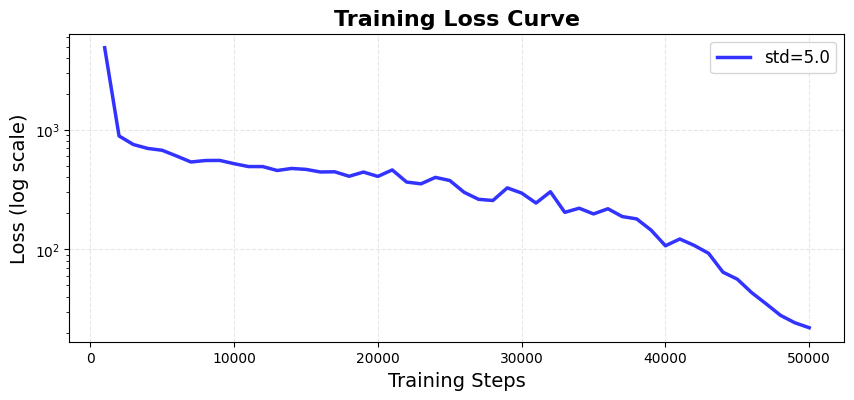

In [13]:
steps = [(i + 1) * 1000 for i in range(len(loss_history))]

plt.figure(figsize=(10, 4))
plt.plot(steps, loss_history, "b-", linewidth=2.5, alpha=0.8, label="std=5.0")

if max(loss_history) / min(loss_history) > 100:
    plt.yscale("log")
    ylabel = "Loss (log scale)"
else:
    ylabel = "Loss"

plt.xlabel("Training Steps", fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title("Training Loss Curve", fontsize=16, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12)
plt.show()


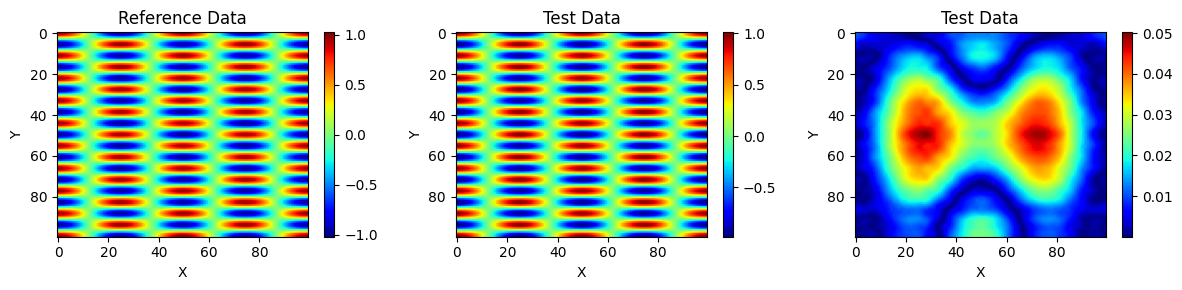

In [14]:
# 创建子图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))

# 绘制参考数据
im1 = ax1.imshow(cube_ref, cmap='jet', aspect='auto')
ax1.set_title('Reference Data')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
plt.colorbar(im1, ax=ax1)

# 绘制测试数据
im2 = ax2.imshow(cube_test, cmap='jet', aspect='auto')
ax2.set_title('Test Data')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(im2, ax=ax2)

# 绘制测试数据
im2 = ax3.imshow(np.abs(cube_test-cube_ref), cmap='jet', aspect='auto')
ax3.set_title('Test Data')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
plt.colorbar(im2, ax=ax3)

plt.tight_layout()
plt.show()

In [15]:
axis = torch.linspace(0, 1.0, 1000).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1).cpu().numpy()
y_ref = targets.view(-1, 1).to(device).cpu().numpy()

scipy.io.savemat("y_pre.mat", {'u': y_test}) 
scipy.io.savemat("y_ref.mat", {'u': y_ref}) 

In [16]:
X_star = lhs(2, 100000)
X_star = torch.tensor(X_star, dtype=torch.float32, device=device)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred, _ = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

Error(L2): 4.33736e-02
